In [2]:
import numpy as np 
from pathlib import Path
import numpy as np
import struct
import mrcfile

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import jax
import matplotlib.pyplot as plt

from kltpicker_3d.tomogram import KLTParticleDetector3D

#jax.config.update("jax_default_device", jax.devices("cpu")[0])

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.5
})

In [3]:
tomogram_path = "tomo_simulation_round_1/tomo_01.2022-04-11T140327+0200/tiltseries_rec.mrc"
with mrcfile.open(tomogram_path, permissive=True) as mrc:
    tomogram = mrc.data
    voxel_size = np.array([
                float(mrc.voxel_size.x),
                float(mrc.voxel_size.y),
                float(mrc.voxel_size.z),
    ], dtype=float)

In [4]:
coords_path = Path("tomo_simulation_round_1/tomo_01.2022-04-11T140327+0200/coords/6gy6_coords.txt")
lines = [line.strip() for line in coords_path.read_text().splitlines() if line.strip()]

count, class_id = map(int, lines[1].split())
coords = np.array([list(map(float, line.split())) for line in lines[3:]])[:,:3]
coords = coords + (np.array(tomogram.shape) / 2)[None,:]

In [27]:
diameter = 240

detector = KLTParticleDetector3D(
    tomogram=tomogram,
    particle_diameter=240,
    mgscale=1/voxel_size[0],  
    num_particles=-1,
    legendre_order=150,
    threshold=0.5,
    max_iter=500,
    max_order=1
)

In [28]:
num_particles, coords = detector.process_tomogram()

/data/home/moshemaymon/.conda/envs/torch/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


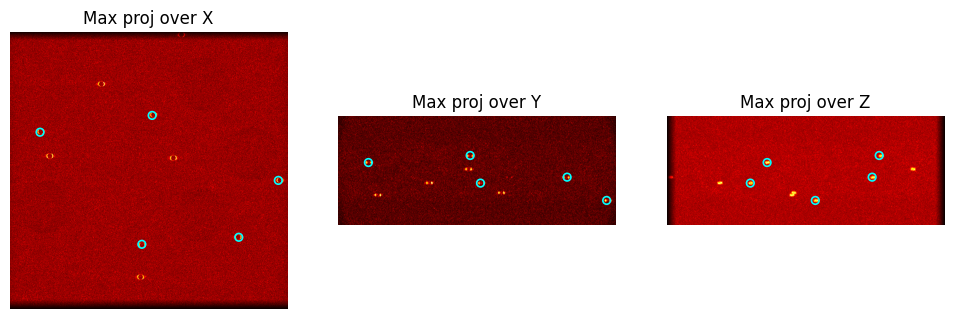

In [29]:
S = np.asarray(tomogram)

fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].scatter(coords[:, 2], coords[:, 1], s=30, facecolors="none", edgecolors="cyan", linewidths=1.2)
ax[0].imshow(S.max(axis=0), cmap="hot"); ax[0].set_title("Max proj over X")
ax[1].imshow(S.max(axis=1), cmap="hot"); ax[1].set_title("Max proj over Y")
ax[1].scatter(coords[:, 2], coords[:, 0], s=30, facecolors="none", edgecolors="cyan", linewidths=1.2)
ax[2].imshow(S.max(axis=2), cmap="hot"); ax[2].set_title("Max proj over Z")
ax[2].scatter(coords[:, 1], coords[:, 0], s=30, facecolors="none", edgecolors="cyan", linewidths=1.2)
plt.tight_layout()
for a in ax: a.axis("off")
plt.show()

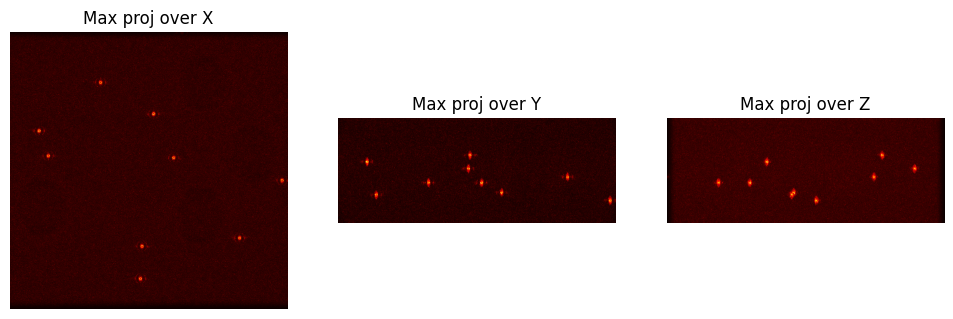

In [31]:
S = np.asarray(detector.score_mat)

fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].imshow(S.max(axis=0), cmap="hot"); ax[0].set_title("Max proj over X")
ax[1].imshow(S.max(axis=1), cmap="hot"); ax[1].set_title("Max proj over Y")
ax[2].imshow(S.max(axis=2), cmap="hot"); ax[2].set_title("Max proj over Z")
plt.tight_layout()
for a in ax: a.axis("off")
plt.show()

In [34]:
tuple(voxel_size.astype(float))

(np.float64(10.204081535339355),
 np.float64(10.204081535339355),
 np.float64(10.204081535339355))

In [35]:
vol = np.transpose(detector.score_mat,(2,1,0))

with mrcfile.new('tomotwin.mrc', overwrite=True) as m:
    m.set_data(vol.astype(np.float32))
    m.voxel_size = tuple(voxel_size.astype(float))   # replace with your voxel spacing